# Advanced: Comparison with HALO-(AC)³ aircraft measurements (1)

Here, we simulate the irradiance at 15 output altitudes along the flight path of the HALO aircraft during the HALO-(AC)³ campaign. The timesteps are filtered for cloud-free conditions and the simulated albedo is compared to aircraft observations over Arctic sea ice.

In [2]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('config/radiosonde_thermal.yaml')
import logging
# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


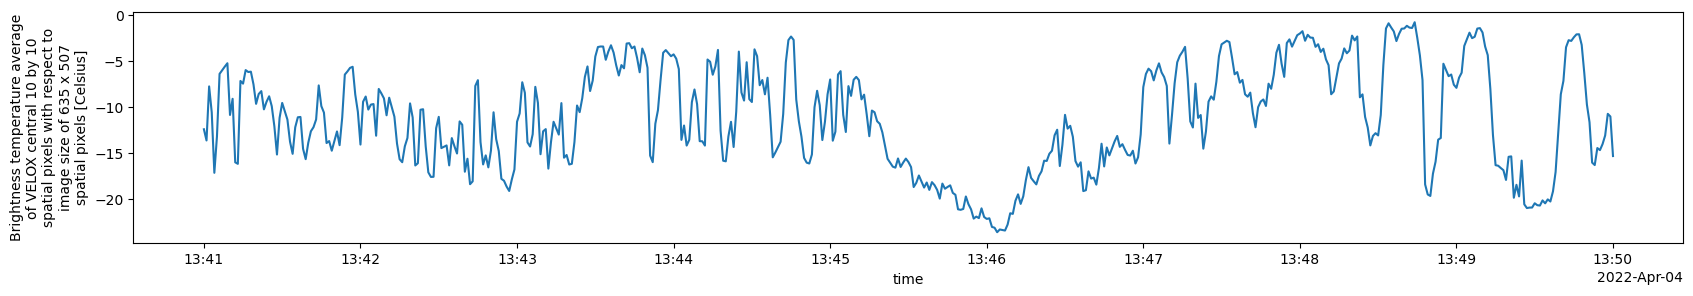

In [3]:
ds = xr.open_dataset('/projekt_agmwend/data/HALO-AC3/02_Flights/HALO-AC3_20220404_HALO_RF13/VELOX/VELOX_327kveL/Processed/to_publish/final/HALO-AC3_HALO_VELOX_BT3_10740nm_20220404_RF13_v3.0.nc').sel(time=slice('2022-04-04T13:41:00', '2022-04-04T13:50:00')).load()

ds.BT_Center.plot(figsize=(20, 3))

In [4]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_bt(time):
    fig, ax = plt.subplots(1, 2, figsize=(7, 3))

    bins = np.linspace(-25, 0, 100)
    ds.BT_2D.isel(time=time).plot(cmap='viridis', vmin=-25, vmax=0, ax=ax[1], cbar_kwargs={'label': 'Brightness Temperature (K)'})
    ds.BT_2D.isel(time=time).plot.hist(ax=ax[0], bins=bins, color='gray', alpha=0.7, histtype='step', lw=2)
    plt.tight_layout()
    plt.show()

interact(plot_bt, time=widgets.IntSlider(min=0, max=len(ds.time)-1, step=1, value=240, description='Time Index'));

interactive(children=(IntSlider(value=240, description='Time Index', max=527), Output()), _dom_classes=('widge…

In [5]:
ds_sel = ds.isel(time=slice(160, 161)).rename(
    {'lat' : 'latitude', 'lon': 'longitude', 'alt': 'altitude'}
)
ds_sel['altitude_halo'] = ds_sel['altitude'] / 1000 
ds_sel = ds_sel.drop_vars('altitude')
ds_sel['altitude'] = ('altitude', np.arange(0, 15, 0.1))
#s_sel['altitude'] = ds_sel['altitude'] / 1000  # Convert altitude to km


In [6]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
config_path = Path('config/radiosonde_thermal.yaml')

# ds_sim = ds_sel.pyradtran.run_uvspec(
#     config_path=config_path,
#     return_dataset=True,
#     save_to_file=True,
#     output_path='data/Simulated_HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc',
# )

ds_sim_cloud_free = ds_sel.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    # surface_temperature_var='surface_temperature',
    # albedo_var='albedo',
    parameter_overrides={
        'output_quantity' : 'brightness',
    },
)

print("\nSimulation complete!")
ds_sim_cloud_free

2025-07-23 23:19:58,658 - pyradtran.interface - INFO - Altitude found as coordinate - using 150 levels for zout: [ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10.  10.1 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1
 11.2 11.3 11.4 11.5 11.6 11.7 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5
 12.6 12.7 12.8 12.9 13.  13.1 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9
 14.  14.1 14.2 14.3 14.4 14.5 14.6 14.7 14.8 14.9]
2025-07-23 23:19:58,659 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250723_231958.nc
20

Running batch spectral simulation...


2025-07-23 23:19:58,903 - pyradtran.core - DEBUG - Time 2022-04-04 13:43:44 -> Closest Sonde: 20220404_49574SOD.dat
2025-07-23 23:19:58,908 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/book/notebooks/work/uvspec_20220404_134344_tmh_f7qy.inp
2025-07-23 23:19:58,909 - pyradtran.core - DEBUG - Running uvspec: /opt/libradtran/2.0.4/bin/uvspec < uvspec_20220404_134344_tmh_f7qy.inp > uvspec_20220404_134344_tmh_f7qy.out
2025-07-23 23:20:00,429 - pyradtran.core - DEBUG - uvspec finished successfully for uvspec_20220404_134344_tmh_f7qy.inp.
2025-07-23 23:20:00,431 - pyradtran.io - DEBUG - Initialized parser with columns: ['zout', 'lambda', 'eup', 'edn', 'edir', 'eglo', 'enet']
2025-07-23 23:20:00,433 - pyradtran.io - DEBUG - Original user columns: ['zout', 'lambda', 'eup', 'edn', 'edir', 'eglo', 'enet']
2025-07-23 23:20:00,433 - pyradtran.io - DEBUG - Brightness output mode: True
2025-07-23 23:20:00,435 - pyradtran.io - IN


Simulation complete!


<xarray.Dataset> Size: 7kB
Dimensions:    (time: 1, altitude: 150)
Coordinates:
  * time       (time) datetime64[ns] 8B 2022-04-04T13:43:44
    latitude   (time) float32 4B 78.21
    longitude  (time) float32 4B 1.024
  * altitude   (altitude) float64 1kB 0.0 0.1 0.2 0.3 ... 14.6 14.7 14.8 14.9
Data variables:
    eup        (time, altitude) float64 1kB 258.4 258.4 258.4 ... 254.1 254.1
    edn        (time, altitude) float64 1kB 194.9 193.6 192.4 ... 157.8 157.7
    edir       (time, altitude) float64 1kB 0.0 0.0 0.0 nan ... nan nan 0.0 0.0
    eglo       (time, altitude) float64 1kB 194.9 193.6 192.4 ... 157.8 157.7
    enet       (time, altitude) float64 1kB -63.56 -64.8 -65.99 ... -96.31 -96.4
Attributes:
    created:                    2025-07-23T23:20:00.500671
    source:                     PyRadtran
    output_type:                integrated_multi_altitude
    num_simulations:            1
    is_brightness_temperature:  1
    generated_by:               pyradtran
    pyradtran_version:          new_io_system

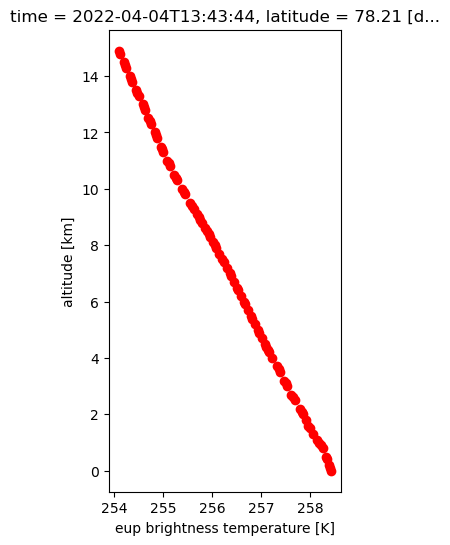

In [7]:
fig, ax = plt.subplots(figsize=(3, 6))

ds_sim_cloud_free.eup.plot(y='altitude', ax=ax, marker='o', color='red', label='Upwelling')

## Simulation Results

Spectral radiative transfer calculations completed using DISORT solver with multi-level output altitude grid.

In [8]:
# Generate cloud layers using the utility functions
from pyradtran.clouds import CloudLayer, CloudGenerator, CloudFileWriter

# Create simple parametric clouds
simple_clouds = CloudGenerator.from_simple_parameters(
    z_base_km=2.0,
    z_top_km=4.0,
    lwc_g_m3=0.1,
    r_eff_um=10.0,
    n_layers=5
)

# Write custom cloud file
custom_wc_file = Path('work/custom_water_cloud.dat')
CloudFileWriter.write_water_cloud_file(
    cloud_layers=simple_clouds,
    output_path=custom_wc_file,
    altitude_resolution_km=0.1
)



2025-07-23 23:20:05,414 - pyradtran.clouds - INFO - Writing water cloud file to work/custom_water_cloud.dat
2025-07-23 23:20:05,417 - pyradtran.clouds - INFO - Wrote 21 altitude levels to work/custom_water_cloud.dat


PosixPath('work/custom_water_cloud.dat')

0 NaNs in CTH; 0 NaNs in thickness


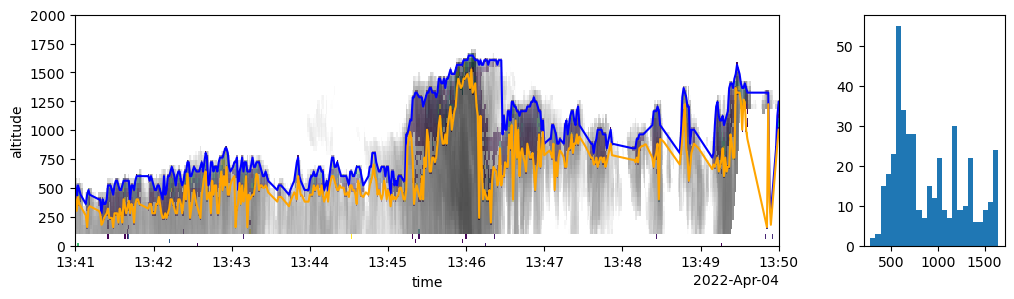

In [52]:
lidar = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bsrgl.nc').sel(time=ds.time).load()
lidar = lidar.where(lidar.backscatter_ratio > 100)
radar = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_radar.nc').sel(time=ds.time).load()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'width_ratios': [1, .2]})

im_lidar = lidar.backscatter_ratio.where(lidar.backscatter_ratio > 100).plot(y='altitude', robust=True, add_colorbar=False, ax=ax)
im_radar = radar.dBZg.plot(y='height', robust=True, cmap='gray_r', alpha=.7, add_colorbar=False, ax=ax)
ax.set_ylim(0, 2000)

def cth_and_layer_thickness(ds, ds_lidar=lidar):
    """ Calculate cloud top height and layer thickness from lidar data.
    """
    # The lidar data is already filtered for backscatter_ratio > 10
    # We can find the cloud top and base by finding the max and min altitude where the data is not NaN
    
    # Ensure the lidar data is aligned with the ds time, using nearest neighbor interpolation
    ds_lidar_sel = ds_lidar.sel(time=ds.time, method='nearest')
    
    # Find cloud top height (highest altitude with significant backscatter)
    cth = ds_lidar_sel.altitude.where(ds_lidar_sel.backscatter_ratio.notnull()).max(dim='altitude')
    
    # Find cloud base height (lowest altitude with significant backscatter)
    cbh = ds_lidar_sel.altitude.where(ds_lidar_sel.backscatter_ratio.notnull()).min(dim='altitude')

    # if cth is smaller than 100 m, set it to NaN
    # if cbh is smaller than 100 m, set it to NaN
    cth = cth.where(cth > 150, np.nan)
    cbh = cbh.where(cbh > 150, np.nan)
    
    # Calculate thickness
    thickness = cth - cbh
    
    return cth, thickness

cth, thickness = cth_and_layer_thickness(ds)

cth_interp = cth.interpolate_na('time')
thickness_interp = thickness.interpolate_na('time')
### assign thickness < 100 to 100
thickness_interp = thickness_interp.where(thickness_interp > 100, 100)
# print nans
print(f'{cth_interp.isnull().sum().values} NaNs in CTH; {thickness_interp.isnull().sum().values} NaNs in thickness')


cth_interp.plot(ax=ax, label='Cloud Top Height', color='blue')
(cth_interp - thickness_interp).plot(ax=ax, label='Cloud Base Height', color='orange')

lidar_bins = np.linspace(np.nanquantile(lidar.backscatter_ratio, 0.01), np.nanquantile(lidar.backscatter_ratio, 0.99), 50)

#lidar.backscatter_ratio.plot.hist(bins=lidar_bins, color='gray', alpha=0.7, histtype='step', lw=2)

_= ax2.hist(cth, bins=25)

In [53]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
config_path = Path('config/radiosonde_thermal.yaml')

# ds_sim = ds_sel.pyradtran.run_uvspec(
#     config_path=config_path,
#     return_dataset=True,
#     save_to_file=True,
#     output_path='data/Simulated_HALO-AC3_HALO_aircraft_broadband_radiation_clear_sky_with_ocean_600s.nc',
# )
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)
from tqdm import tqdm

ds_sim_cloudy_list = []


for i in tqdm(range(len(ds.time))):
    # Select the current time slice
    ds_to_sim = ds.isel(time=[i]).copy().rename(
        {'lat': 'latitude', 'lon': 'longitude'}
    )  # Drop unnecessary variables for simulation
    alt = ds_to_sim.alt / 1e3 # Use mean altitude for the simulation
    #print(f"Selected altitude for simulation: {alt.values} m")
    #ds_to_sim = ds_to_sim.drop_vars(['altitude'])
    ds_to_sim['altitude'] = ('altitude', alt.values)  # Set altitude resolution to 100 m
    cth_i = cth_interp.isel(time=i).values / 1000  # Convert to km
    thickness_i = thickness_interp.isel(time=i).values / 1000  # Convert to km

    #print(f"Simulating time index {i} with CTH={cth_i:.2f} km and thickness={thickness_i:.2f} km")

    # Create simple parametric clouds
    simple_clouds = CloudGenerator.from_simple_parameters(
        z_base_km=cth_i - thickness_i,
        z_top_km=cth_i,
        lwc_g_m3=0.1,
        r_eff_um=10.0,
        n_layers=2
    )

    # Write custom cloud file
    custom_wc_file = Path('work/custom_water_cloud.dat')
    CloudFileWriter.write_water_cloud_file(
        cloud_layers=simple_clouds,
        output_path=custom_wc_file,
        altitude_resolution_km=0.01
    )


    ds_sim_cloudy = ds_to_sim.pyradtran.run_uvspec(
        config_path=config_path,
        return_dataset=True,
        save_to_file=False,
        # surface_temperature_var='surface_temperature',
        # albedo_var='albedo',
        parameter_overrides={
            'output_quantity' : 'brightness',
            'wc_file 1D' : 'custom_water_cloud.dat',  # Use the water cloud file
        },
    )

    ds_sim_cloudy['cloud_top_height'] = cth_i
    ds_sim_cloudy['cloud_thickness'] = thickness_i

    ds_sim_cloudy_list.append(ds_sim_cloudy)


print("\nSimulation complete!")


Running batch spectral simulation...


  0%|          | 0/528 [00:00<?, ?it/s]2025-07-23 23:36:06,699 - pyradtran.config - INFO - Loading configuration from: config/radiosonde_thermal.yaml
2025-07-23 23:36:06,714 - pyradtran.config - INFO - Configuration loaded successfully.
  0%|          | 1/528 [00:00<07:07,  1.23it/s]2025-07-23 23:36:07,508 - pyradtran.config - INFO - Loading configuration from: config/radiosonde_thermal.yaml
2025-07-23 23:36:07,514 - pyradtran.config - INFO - Configuration loaded successfully.
  0%|          | 2/528 [00:01<07:29,  1.17it/s]2025-07-23 23:36:08,393 - pyradtran.config - INFO - Loading configuration from: config/radiosonde_thermal.yaml
2025-07-23 23:36:08,398 - pyradtran.config - INFO - Configuration loaded successfully.
  1%|          | 3/528 [00:02<07:23,  1.18it/s]2025-07-23 23:36:09,226 - pyradtran.config - INFO - Loading configuration from: config/radiosonde_thermal.yaml
2025-07-23 23:36:09,234 - pyradtran.config - INFO - Configuration loaded successfully.
  1%|          | 4/528 [00:0


Simulation complete!


In [54]:
simple_clouds

[CloudLayer(z_bottom_km=np.float64(1.0040160642570282), z_top_km=np.float64(1.1244979919678715), lwc_g_m3=0.1, iwc_g_m3=0.0, r_eff_um=10.0, cloud_fraction=1.0),
 CloudLayer(z_bottom_km=np.float64(1.1244979919678715), z_top_km=np.float64(1.2449799196787148), lwc_g_m3=0.1, iwc_g_m3=0.0, r_eff_um=10.0, cloud_fraction=1.0)]

In [55]:
ds_sim_cloudy = xr.concat(ds_sim_cloudy_list, dim='time')
ds_sim_cloudy

<xarray.Dataset> Size: 38kB
Dimensions:           (time: 528)
Coordinates:
  * time              (time) datetime64[ns] 4kB 2022-04-04T13:41:00 ... 2022-...
    latitude          (time) float32 2kB 78.3 78.3 78.3 ... 77.95 77.95 77.95
    longitude         (time) float32 2kB -0.5636 -0.5539 -0.5442 ... 4.496 4.502
Data variables:
    eup               (time) float64 4kB 262.0 262.5 262.0 ... 260.6 257.9 257.0
    edn               (time) float64 4kB 99.64 99.64 99.64 ... 99.67 99.67 99.67
    edir              (time) float64 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    eglo              (time) float64 4kB 99.64 99.64 99.64 ... 99.67 99.67 99.67
    enet              (time) float64 4kB -162.3 -162.9 -162.4 ... -158.2 -157.3
    cloud_top_height  (time) float64 4kB 0.5221 0.4016 0.5221 ... 1.124 1.245
    cloud_thickness   (time) float64 4kB 0.1 0.1 0.1004 ... 0.1 0.241 0.241
Attributes:
    created:                    2025-07-23T23:36:07.502767
    source:                     PyRadtran
    output_type:                integrated_single_altitude
    num_simulations:            1
    is_brightness_temperature:  1
    generated_by:               pyradtran
    pyradtran_version:          new_io_system

Median brightness temperature: -10.89 K


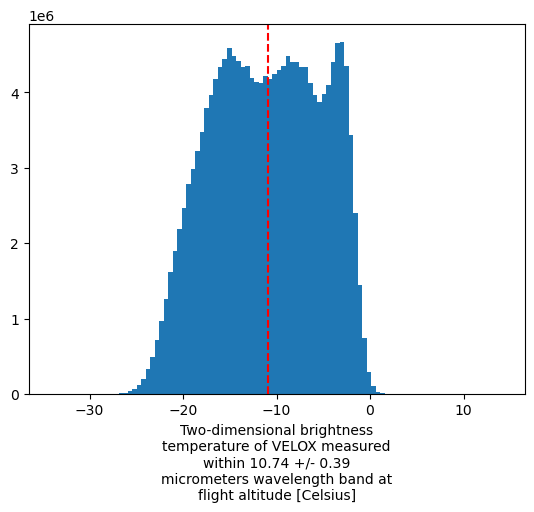

In [59]:
ds.BT_2D.plot.hist(bins=100) 

from scipy.signal import find_peaks

### plot the median brightness temperature for the first 15 time steps
median = ds.BT_2D.quantile(0.5, ['x','y', 'time'])
plt.axvline(median, color='red', linestyle='--', label='Median BT')
print(f"Median brightness temperature: {median.values:.2f} K")

### we use that as a threshold for the brightness temperature to determine the cloud presence
ds_cloudy = ds.where(ds.BT_2D < median)

/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_933449/863506041.py:33: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax_scatter.legend(loc='upper left')
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_933449/863506041.py:44: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  a.legend()


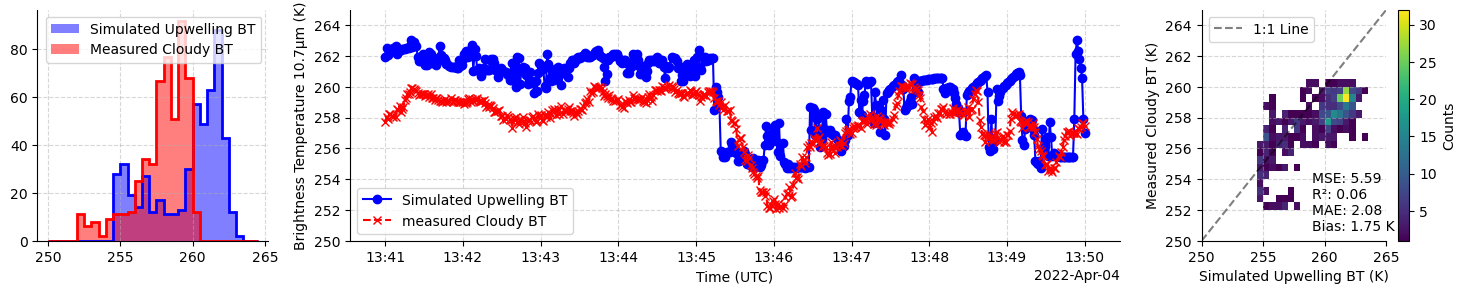

In [122]:
fig, (ax_hists, ax, ax_scatter) = plt.subplots(1, 3, figsize=(18, 3), gridspec_kw={'width_ratios': [.3, 1, .3]})

ds_sim_cloudy.eup.plot(marker='o', color='blue', label='Simulated Upwelling BT', ax=ax)
(ds_cloudy.BT_2D.mean(['x', 'y']) + 273.15).plot(label='measured Cloudy BT', color='red', linestyle='--', marker='x', ax=ax)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Brightness Temperature 10.7µm (K)')
ax.set_ylim(250, 265)   

X = ds_sim_cloudy.eup.values
Y = (ds_cloudy.BT_2D.mean(['x', 'y']) + 273.15).values
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask]
Y = Y[nan_mask]
bins = np.arange(250, 265, .5)
h = ax_scatter.hist2d(X, Y, label='Simulated Upwelling BT', bins=bins, cmin=1, cmap='viridis')
ax_scatter.set_xlabel('Simulated Upwelling BT (K)')
ax_scatter.set_ylabel('Measured Cloudy BT (K)')
# add a colorbar to the scatter plot
cbar = plt.colorbar(h[3], ax=ax_scatter, label='Counts')

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(X, Y)
r2 = r2_score(X, Y)
mae = mean_absolute_error(X, Y)
bias = np.mean(X - Y)

stats_text = f'MSE: {mse:.2f}\nR²: {r2:.2f}\nMAE: {mae:.2f}\nBias: {bias:.2f} K'
ax_scatter.text(0.6, 0.3, stats_text, transform=ax_scatter.transAxes, fontsize=10, verticalalignment='top')
ax_scatter.set_xlim(250, 265)
ax_scatter.set_ylim(250, 265)
ax_scatter.plot([250, 265], [250, 265], color='black', linestyle='--', label='1:1 Line', alpha=0.5)

ax_scatter.legend(loc='upper left')

ax_hists.hist(ds_sim_cloudy.eup.values, bins=bins, color='blue', alpha=0.5, histtype='stepfilled', lw=2, label='Simulated Upwelling BT')
ax_hists.hist(ds_sim_cloudy.eup.values, bins=bins, color='blue', histtype='step', lw=2)

ax_hists.hist((ds_cloudy.BT_2D.mean(['x', 'y']) + 273.15).values, bins=bins, color='red', alpha=0.5, histtype='stepfilled', lw=2, label='Measured Cloudy BT')
ax_hists.hist((ds_cloudy.BT_2D.mean(['x', 'y']) + 273.15).values, bins=bins, color='red', histtype='step', lw=2)

for a in (ax, ax_scatter, ax_hists):
    a.spines[['top', 'right']].set_visible(False)
    a.grid(True, linestyle='--', alpha=0.5)
    a.legend()
    a.set_title('')
    #a.set_ylim(250, 265)

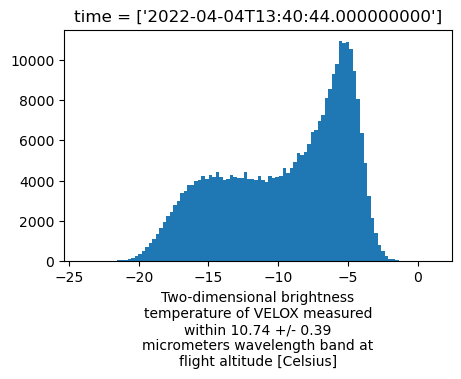

In [112]:
fig, ax = plt.subplots(figsize=(5, 3))

h = ds_sel.BT_2D.plot.hist(bins=100)

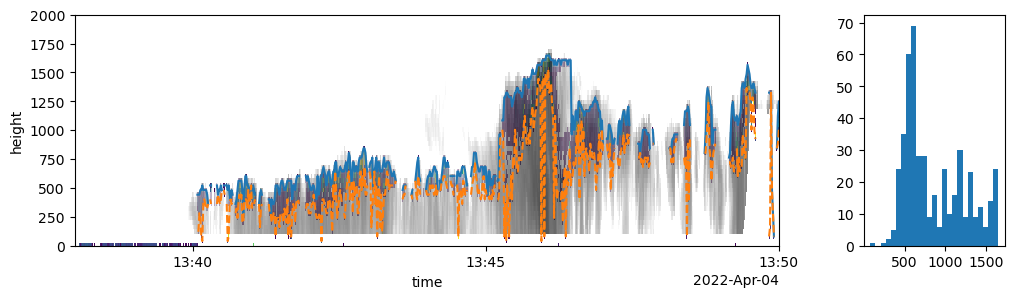

ValueError: Dimensions {'time'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'altitude': 250})

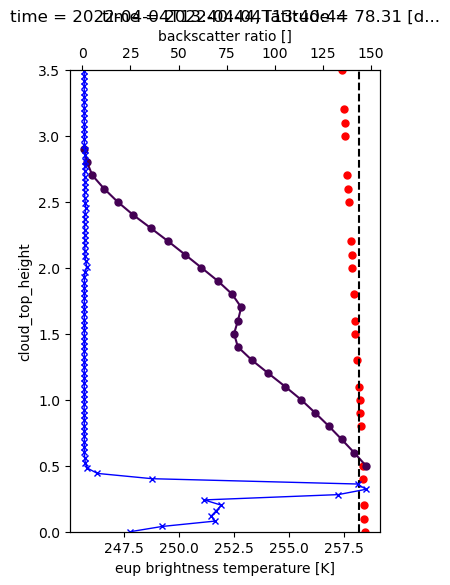

In [135]:
fig, ax = plt.subplots(figsize=(4, 6))

ax.set_prop_cycle(plt.cycler(color=plt.cm.viridis(np.linspace(0, 1, len(ds_sim_cloudy.cloud_top_height)))))

lidar = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bsrgl.nc')
lidar['altitude'] = lidar['altitude'] / 1000

ds_sim_cloud_free.eup.plot(y='altitude', ax=ax, marker='o', color='red', label='Upwelling Cloud free', lw=0, ms=5)
#_ = ds_sim_cloudy.eup.plot(y='altitude', ax=ax, marker='o', label='Upwelling with Cloud', hue='cloud_top_height',)

ds_sim_cloudy.eup.plot(y='cloud_top_height', ax=ax, marker='o', ms=5, label='Upwelling with Cloud')

ax.set_ylim(0, 3.5)

### plot the measured brightness temperature

ax.axvline(273.15 - 15, color='black', linestyle='--', label='Measured BT @ 10.7 µm')

ax_twin = ax.twiny()
lidar.sel(time=ds_sel.time).backscatter_ratio.plot(y='altitude', ax=ax_twin, color='blue', label='Lidar Backscatter Ratio', lw=1, marker='x', ms=5)

lidar_cth = lidar.sel(time=ds_sel.time).altitude.where(lidar.sel(time=ds_sel.time).backscatter_ratio > 1.5, drop=True).first()


ax.set_xlabel('Upwelling Brightness Temperature (K)')
ax.set_ylabel('Altitude (km)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)